## Movies Rating Prediction

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands the movie rating through various classes like genre,duration,director,year,actor1,actor2,actor3.

### 2) Data collection
- Dataset source -https://www.kaggle.com/datasets/adrianmcmahon/imdb-india-movies
- This dataset contain 15509x10 rows and columns. 

#### Import Libraries(numpy,matplotlib) and packages(pandas)

In [110]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#### Import the csv data as pandas dataframe

##### Detect the encoding using chardet

In [111]:
import chardet

In [112]:
with open("IMDb Movies India.csv","rb") as f:
    result = chardet.detect(f.read())
    
print(result)

{'encoding': 'MacRoman', 'confidence': 0.11211302766194868, 'language': 'ms', 'mime_type': 'text/plain'}


In [113]:
df = pd.read_csv("IMdb Movies India.csv",encoding="ISO-8859-1")

#### Show top 5 records

In [114]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


#### Shape of the dataset

In [115]:
df.shape

(15509, 10)

### 3. Data Checks to perform

- Check Missing value and handle them
- Check Duplicates
- Drop unwanted columns
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

#### Check missing values

In [116]:
df.isna().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [117]:
df = df.drop(columns=['Name','Votes','Duration'])

In [118]:
df.head(3)

,Year,Genre,Rating,Director,Actor 1,Actor 2,Actor 3
0,NaN,Drama,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,(2019),Drama,7.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,(2021),"Drama, Musical",NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana


In [119]:
df.dropna(subset=['Year','Genre','Rating','Director','Actor 1','Actor 2','Actor 3'], inplace=True)

In [120]:
df.head(2)

,Year,Genre,Rating,Director,Actor 1,Actor 2,Actor 3
1,(2019),Drama,7.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,(2019),"Comedy, Romance",4.4,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor


In [121]:
df.isna().sum()

Year        0
Genre       0
Rating      0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [122]:
df.shape

(7558, 7)

In [123]:
df.duplicated().sum()

np.int64(0)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7558 entries, 1 to 15508
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      7558 non-null   object 
 1   Genre     7558 non-null   object 
 2   Rating    7558 non-null   float64
 3   Director  7558 non-null   object 
 4   Actor 1   7558 non-null   object 
 5   Actor 2   7558 non-null   object 
 6   Actor 3   7558 non-null   object 
dtypes: float64(1), object(6)
memory usage: 472.4+ KB


In [125]:
df.nunique()

Year          92
Genre        416
Rating        84
Director    2956
Actor 1     2415
Actor 2     2783
Actor 3     3031
dtype: int64

In [126]:
df['Genre'].value_counts()

Genre
Drama                          1137
Drama, Romance                  443
Action, Crime, Drama            417
Action                          391
Drama, Family                   291
                               ... 
Family, Comedy, Drama             1
Fantasy, Horror, Romance          1
Crime, Horror, Romance            1
Drama, Mystery, Sci-Fi            1
Animation, Drama, Adventure       1
Name: count, Length: 416, dtype: int64

In [127]:
df['Year'].value_counts()

Year
(2019)    238
(2017)    223
(2018)    214
(2015)    188
(2016)    184
         ... 
(1939)      4
(1931)      3
(1932)      2
(1934)      2
(1917)      1
Name: count, Length: 92, dtype: int64

In [128]:
df['Director'].value_counts()

Director
Mahesh Bhatt            45
David Dhawan            43
Hrishikesh Mukherjee    42
Shakti Samanta          38
Kanti Shah              37
                        ..
Paul Zils                1
K. Mishra                1
Teja                     1
Sooni Taraporevala       1
Aryan Neeraaj Anand      1
Name: count, Length: 2956, dtype: int64

In [129]:
df['Actor 1'].value_counts()

Actor 1
Jeetendra             140
Dharmendra            134
Mithun Chakraborty    130
Ashok Kumar           125
Rajesh Khanna         118
                     ... 
Jayant Gadekar          1
Jayalalitha J           1
Abuzar Akhtar           1
Amitkumar Sharma        1
Partho A. Gupte         1
Name: count, Length: 2415, dtype: int64

In [130]:
df['Actor 2'].value_counts()

Actor 2
Rekha                  79
Hema Malini            71
Mithun Chakraborty     59
Dharmendra             55
Mala Sinha             43
                       ..
Omna                    1
Apurva Godbole          1
Michalina Olszanska     1
Karan Kundra            1
Rukhsar Rehman          1
Name: count, Length: 2783, dtype: int64

In [131]:
df['Actor 3'].value_counts()

Actor 3
Pran                  74
Anupam Kher           55
Shakti Kapoor         46
Prem Chopra           44
Mithun Chakraborty    42
                      ..
Ravi Baswani           1
Arjun Chakraborty      1
Mohini Nillakant       1
Kishori Ambiye         1
Sunita Devi            1
Name: count, Length: 3031, dtype: int64

In [132]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [133]:
df.head(2)

,Year,Genre,Rating,Director,Actor 1,Actor 2,Actor 3
1,(2019),Drama,7.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,(2019),"Comedy, Romance",4.4,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor


In [134]:
X = df.drop(columns=['Rating'])
y = df['Rating']

In [135]:
print(X)

         Year                      Genre           Director           Actor 1  \
1      (2019)                      Drama      Gaurav Bakshi      Rasika Dugal   
3      (2019)            Comedy, Romance         Ovais Khan           Prateik   
5      (1997)     Comedy, Drama, Musical       Rahul Rawail        Bobby Deol   
6      (2005)        Drama, Romance, War     Shoojit Sircar   Jimmy Sheirgill   
8      (2012)  Horror, Mystery, Thriller      Allyson Patel         Yash Dave   
...       ...                        ...                ...               ...   
15501  (1992)       Action, Crime, Drama  Bharat Rangachary        Dharmendra   
15503  (1989)       Action, Crime, Drama    S.P. Muthuraman       Chiranjeevi   
15504  (1988)                     Action      Mahendra Shah  Naseeruddin Shah   
15505  (1999)              Action, Drama         Kuku Kohli      Akshay Kumar   
15508  (1998)              Action, Drama       K.C. Bokadia        Dharmendra   

                      Actor

In [136]:
print(y)

1        7.0
3        4.4
5        4.7
6        7.4
8        5.6
        ... 
15501    5.3
15503    5.8
15504    4.6
15505    4.5
15508    6.2
Name: Rating, Length: 7558, dtype: float64


In [137]:
X.isna().sum()

Year        0
Genre       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [138]:
# 2. Initialize the encoder (smooths rare categories automatically)
encoder = TargetEncoder(random_state=42).set_output(transform='pandas')

# 3. Fit and transform all categorical columns at once
X= encoder.fit_transform(X,y)

# 4. Convert back to a readable DataFrame
X = pd.DataFrame(X, columns=X.columns)
print(X)

           Year     Genre  Director   Actor 1   Actor 2   Actor 3
1      6.286266  6.354144  5.810569  6.700000  5.810569  5.810569
3      6.239483  5.665932  5.805292  6.045453  5.805292  4.500000
5      5.324450  6.293065  5.336399  4.517395  5.892343  6.096240
6      5.282217  6.228678  7.465835  5.256845  7.300000  6.767187
8      5.551072  6.011718  5.814768  5.814768  6.084282  5.814768
...         ...       ...       ...       ...       ...       ...
15501  5.459524  5.617523  5.864059  5.835216  6.138556  4.941541
15503  5.336748  5.617523  5.808196  6.135672  5.805292  6.026520
15504  5.630503  5.040320  4.485773  5.902435  2.800000  5.805292
15505  5.391900  5.505642  5.344999  5.384299  4.458886  5.699894
15508  5.169695  5.505642  4.184586  5.695322  5.517952  4.674779

[7558 rows x 6 columns]


In [139]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((6046, 6), (1512, 6))

#### Create an Evaluate Function to give all metrics after model Training

In [140]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [141]:
models = {

    "Linear Regression": LinearRegression(),

    "Lasso": Lasso(),

    "Ridge": Ridge(),

    "KNN": KNeighborsRegressor(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "AdaBoost": AdaBoostRegressor(random_state=42),

    "XGBoost": XGBRegressor(random_state=42),

    "CatBoost": CatBoostRegressor(verbose=False, random_state=42)

}

## Results

In [142]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    train_mae, train_rmse, train_r2 = evaluate_model(y_train, train_pred)

    test_mae, test_rmse, test_r2 = evaluate_model(y_test, test_pred)

    results.append([

        name,

        train_r2,

        test_r2,

        test_mae,

        test_rmse

    ])

    print("="*60)

    print(name)

    print("Train R2 :", train_r2)

    print("Test R2  :", test_r2)

    print("MAE      :", test_mae)

    print("RMSE     :", test_rmse)

Linear Regression
Train R2 : 0.2682620316579679
Test R2  : 0.2701850280199174
MAE      : 0.900764576786898
RMSE     : 1.1628535880274848
Lasso
Train R2 : 0.0
Test R2  : -4.203639428990158e-06
MAE      : 1.101480842640287
RMSE     : 1.3611925571832808
Ridge
Train R2 : 0.2682620154238895
Test R2  : 0.2701815328321956
MAE      : 0.9007682272679391
RMSE     : 1.1628563725597791
KNN
Train R2 : 0.44151295577519234
Test R2  : 0.17801873600394091
MAE      : 0.9569179894179896
RMSE     : 1.2340978968654062
Decision Tree
Train R2 : 0.9903561576890543
Test R2  : -0.5204720698197587
MAE      : 1.297982804232804
RMSE     : 1.6784479437861632
Random Forest
Train R2 : 0.8869096074220538
Test R2  : 0.25123829275892295
MAE      : 0.9142793099647267
RMSE     : 1.1778513007509874
AdaBoost
Train R2 : 0.2437563880612299
Test R2  : 0.2121216654377971
MAE      : 0.9595963626940003
RMSE     : 1.2082261528024152
XGBoost
Train R2 : 0.7680748693823991
Test R2  : 0.18740480516282498
MAE      : 0.9613372676902348


In [143]:
results_df = pd.DataFrame(results, columns=[

    "Model",

    "Train R2",

    "Test R2",

    "MAE",

    "RMSE"

])

results_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,MAE,RMSE
0,Linear Regression,0.268262,0.270185,0.900765,1.162854
2,Ridge,0.268262,0.270182,0.900768,1.162856
8,CatBoost,0.586686,0.259677,0.897891,1.171196
5,Random Forest,0.886910,0.251238,0.914279,1.177851
6,AdaBoost,0.243756,0.212122,0.959596,1.208226
7,XGBoost,0.768075,0.187405,0.961337,1.227032
3,KNN,0.441513,0.178019,0.956918,1.234098
1,Lasso,0.000000,-0.000004,1.101481,1.361193
4,Decision Tree,0.990356,-0.520472,1.297983,1.678448


In [144]:
best_model = RandomForestRegressor(random_state=42)

best_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [145]:
predictions = best_model.predict(X_test)

prediction_df = pd.DataFrame({

    "Actual Rating": y_test.values,

    "Predicted Rating": predictions

})

prediction_df.head(10)

,Actual Rating,Predicted Rating
0,7.4,7.030000
1,4.9,6.057000
2,6.5,6.129000
3,5.7,6.496750
4,7.0,6.390000
5,4.1,4.831000
6,5.7,4.221000
7,6.9,6.080333
8,5.4,5.422000
9,6.9,7.203000


### Plotting

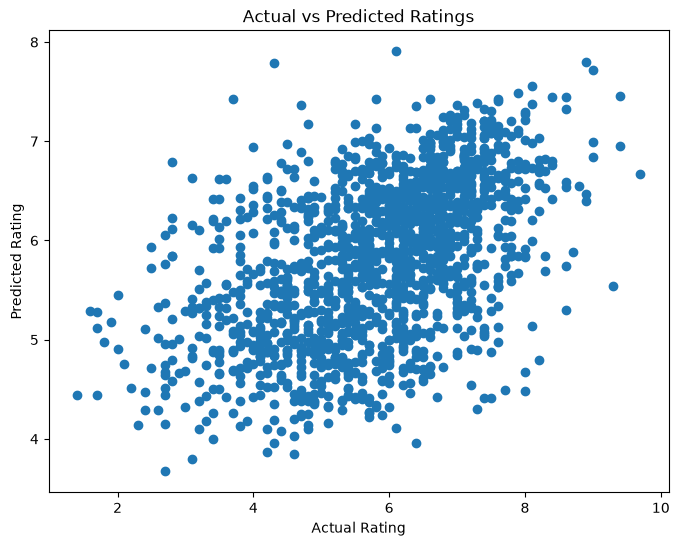

In [146]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.show()